In [ ]:
#bibliotecas que estao sendo utilizadas

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url, sep=',')

print(f"Total de colunas: {len(df.columns)}\n")

print(df.dtypes)

Total de colunas: 21

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [ ]:
#mudando a total charges ( unica que estava com problemas de tipo )
#df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
#print("Novo formato da coluna TotalCharges:")
#print(df['TotalCharges'].dtypes)

print(f"Total de colunas: {len(df.columns)}\n")
print(df.dtypes)

Total de colunas: 21

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [ ]:
print("    ( nulos )    ")
print(df.isnull().sum())

print("\n    ( Duplicadas )   ")
print(df.duplicated().sum())

    ( nulos )    
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

    ( Duplicadas )   
0


In [ ]:
import pandas as pd
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url, sep=',')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df = df.dropna()
print("apos limpeza: ")
print(df.isnull().sum())

apos limpeza: 
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
import plotly.express as px
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)
print("Gerando gráfico de Análise Exploratória...")
grafico_contrato = px.histogram(df, x='Contract', color='Churn', barmode='group',
                                title='Cancelamentos por Tipo de Contrato')
grafico_contrato.show()

Gerando gráfico de Análise Exploratória...


In [ ]:
print("Gerando Gráfico de Caixa (Boxplot)...")

grafico_outliers = px.box(df, x='Churn', y='MonthlyCharges',
                          title='Mensalidades vs Cancelamento (Busca por Extremos)',
                          color='Churn')
grafico_outliers.show()

Gerando Gráfico de Caixa (Boxplot)...


In [ ]:
import pandas as pd

url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url, sep=',')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

# Mostra as 3 primeiras linhas da tabela antes do get_dummies
print("Tabela ANTES da transformação matemática:")
display(df.head(3))

pd.set_option('future.no_silent_downcasting', True)
y = df['Churn'].replace({'Yes': 1, 'No': 0})
X = df.drop('Churn', axis=1)
X = X.drop('customerID', axis=1)
X = pd.get_dummies(X, drop_first=True)

print( "Tabelas depois da transformação")
display(df.head(3))

Tabela ANTES da transformação matemática:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


Tabelas depois da transformação


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


------------------------------------------------------------------------------------------
RESULTADOS DO MODELO KNN:
------------------------------------------------------------------------------------------
Acurácia: 0.76
Precisão: 0.54
Recall:   0.50
F1 Score: 0.52
------------------------------------------------------------------------------------------


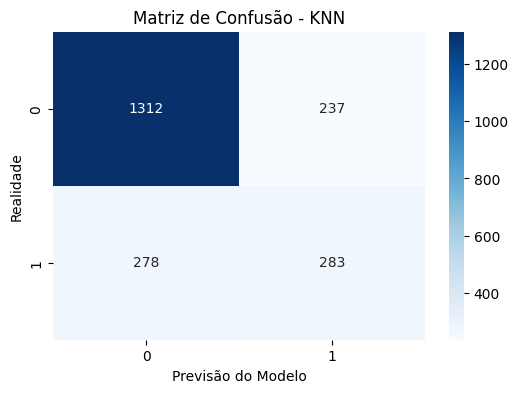

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url, sep=',')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

pd.set_option('future.no_silent_downcasting', True)
y = df['Churn'].replace({'Yes': 1, 'No': 0})
X = df.drop('Churn', axis=1)
X = X.drop('customerID', axis=1)
X = pd.get_dummies(X, drop_first=True)

y = y.astype(int)

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_treino_padrao = scaler.fit_transform(X_treino)
X_teste_padrao = scaler.transform(X_teste)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_treino_padrao, y_treino)

previsoes = knn.predict(X_teste_padrao)
espacamento = "-"
print(espacamento*90)
print("RESULTADOS DO MODELO KNN:")
espacamento = "-"
print(espacamento*90)
print(f"Acurácia: {accuracy_score(y_teste, previsoes):.2f}")
print(f"Precisão: {precision_score(y_teste, previsoes):.2f}")
print(f"Recall:   {recall_score(y_teste, previsoes):.2f}")
print(f"F1 Score: {f1_score(y_teste, previsoes):.2f}")
espacamento = "-"
print(espacamento*90)

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_teste, previsoes), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - KNN')
plt.ylabel('Realidade')
plt.xlabel('Previsão do Modelo')
plt.show()

------------------------------------------------------------------------------------------
RESULTADOS DO MODELO ÁRVORE DE DECISÃO:
------------------------------------------------------------------------------------------
Acurácia: 0.73
Precisão: 0.48
Recall:   0.52
F1 Score: 0.50
------------------------------------------------------------------------------------------


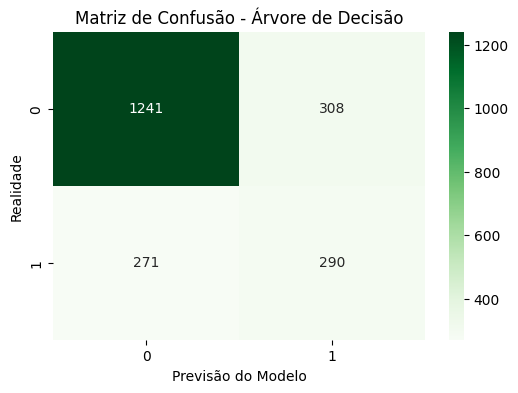

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Recarregando e preparando os dados para garantir que as variáveis existam
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url, sep=',')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

pd.set_option('future.no_silent_downcasting', True)
y = df['Churn'].replace({'Yes': 1, 'No': 0}).astype(int)
X = df.drop(['Churn', 'customerID'], axis=1)
X = pd.get_dummies(X, drop_first=True)

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_treino_padrao = scaler.fit_transform(X_treino)
X_teste_padrao = scaler.transform(X_teste)

# Treinando a Árvore de Decisão
arvore = DecisionTreeClassifier(random_state=42)
arvore.fit(X_treino_padrao, y_treino)

previsoes_tree = arvore.predict(X_teste_padrao)

espacamento = "-"
print(espacamento*90)
print("RESULTADOS DO MODELO ÁRVORE DE DECISÃO:")
print(espacamento*90)
print(f"Acurácia: {accuracy_score(y_teste, previsoes_tree):.2f}")
print(f"Precisão: {precision_score(y_teste, previsoes_tree):.2f}")
print(f"Recall:   {recall_score(y_teste, previsoes_tree):.2f}")
print(f"F1 Score: {f1_score(y_teste, previsoes_tree):.2f}")
print(espacamento*90)

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_teste, previsoes_tree), annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusão - Árvore de Decisão')
plt.ylabel('Realidade')
plt.xlabel('Previsão do Modelo')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but RandomForestClassifier was fitted with feature names



------------------------------------------------------------------------------------------
RESULTADOS DO MODELO RANDOM FOREST:
------------------------------------------------------------------------------------------
Acurácia: 0.69
Precisão: 0.45
Recall:   0.81
F1 Score: 0.58
------------------------------------------------------------------------------------------


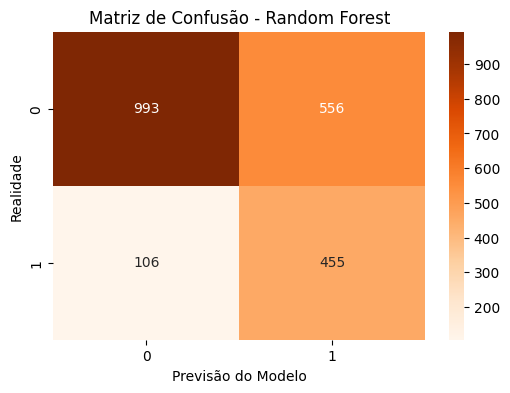

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Recarregando e preparando os dados para garantir consistência total entre as comparações
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url, sep=',')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

pd.set_option('future.no_silent_downcasting', True)
y = df['Churn'].replace({'Yes': 1, 'No': 0}).astype(int)
X = df.drop(['Churn', 'customerID'], axis=1)
X = pd.get_dummies(X, drop_first=True)

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_treino_padrao = scaler.fit_transform(X_treino)
X_teste_padrao = scaler.transform(X_teste)

# Treinando o modelo de Floresta Randômica (Random Forest)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_treino, y_treino)

previsoes_rf = rf.predict(X_teste_padrao)

espacamento = "-"
print(espacamento*90)
print("RESULTADOS DO MODELO RANDOM FOREST:")
print(espacamento*90)
print(f"Acurácia: {accuracy_score(y_teste, previsoes_rf):.2f}")
print(f"Precisão: {precision_score(y_teste, previsoes_rf):.2f}")
print(f"Recall:   {recall_score(y_teste, previsoes_rf):.2f}")
print(f"F1 Score: {f1_score(y_teste, previsoes_rf):.2f}")
print(espacamento*90)

# Matriz de Confusão
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_teste, previsoes_rf), annot=True, fmt='d', cmap='Oranges')
plt.title('Matriz de Confusão - Random Forest')
plt.ylabel('Realidade')
plt.xlabel('Previsão do Modelo')
plt.show()

In [ ]:
import pickle
import pandas as pd

with open('modelo_churn.pkl', 'wb') as file:
    pickle.dump(knn, file)

with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

with open('modelo_churn.pkl', 'rb') as file:
    modelo_carregado = pickle.load(file)

cliente_real_teste = X_teste.iloc[[0]]

cliente_real_teste_padrao = scaler.transform(cliente_real_teste)

try:
    predicao = modelo_carregado.predict(cliente_real_teste_padrao)

    print(f"O modelo foi exportado e reutilizado com sucesso!")
    print(f"Resultado da previsão: {'Churn (Saiu)' if predicao[0] == 1 else 'Fiel (Ficou)'}")

except Exception as e:
    print(f"Erro ao testar o modelo: {e}")

O modelo foi exportado e reutilizado com sucesso!
Resultado da previsão: Fiel (Ficou)


In [ ]:
import pickle
from google.colab import files

with open('modelo_correto.pkl', 'wb') as arquivo:
    pickle.dump(rf, arquivo)

files.download('modelo_correto.pkl')

print("O modelo verdadeiro foi salvo e o download foi iniciado!")

with open('modelo_correto.pkl', 'rb') as arquivo_carregado:
    modelo_floresta_carregado = pickle.load(arquivo_carregado)

print("\nModelo de Floresta Aleatória carregado com sucesso!")
print(f"Tipo do modelo carregado: {type(modelo_floresta_carregado)}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

O modelo verdadeiro foi salvo e o download foi iniciado!

Modelo de Floresta Aleatória carregado com sucesso!
Tipo do modelo carregado: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
